In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('full_image_data_feb_25.csv', low_memory=False)

target_cks = [
    'CK_Measurements of the Earth',
    'CK_Correlation Between Distances on Earth and Locations of Stars', 
    'CK_Circle and Diameter Rule', 
    'CK_Assumed Parallellity of the Sun Rays',
    'CK_Planets Sizes and Distances'
]

# Drop na
df_clean = df.dropna(subset=['year', 'place', 'custom_identifier']).copy()

# Convert custom_identifier to an integer (if applicable) then to string for categorical plotting
try:
    df_clean['custom_identifier_str'] = df_clean['custom_identifier'].astype(float).astype(int).astype(str)
except:
    df_clean['custom_identifier_str'] = df_clean['custom_identifier'].astype(str)



In [22]:
# Create an index mapping custom_id to part_or_adaption_label
print("\n--- Custom ID (Color) to Part or Adaption Label Index ---\n")

if 'part_or_adaption_label' in df_clean.columns:
    filtered = df_clean[df_clean['cks'].isin(target_cks)]
    mapping = filtered[['custom_identifier_str', 'part_or_adaption_label']].dropna().drop_duplicates()
    mapping['custom_identifier_int'] = mapping['custom_identifier_str'].astype(int)
    mapping = mapping.sort_values('custom_identifier_int')
    
    # Display in a nice pandas DataFrame without the index
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', None)
    display_df = mapping[['custom_identifier_str', 'part_or_adaption_label']].rename(
        columns={'custom_identifier_str': 'Custom ID', 'part_or_adaption_label': 'Part or Adaption Label'}
    )
    display(display_df.style.hide(axis="index"))
else:
    print("Column 'part_or_adaption_label' not found in the dataset.")



--- Custom ID (Color) to Part or Adaption Label Index ---



Custom ID,Part or Adaption Label
100,Tractatus de sphaera
110,Introduction by d'Étaples
124,Introduction to geometry by A. Piccolomini
177,Introduction to Geometry and Physics by Mauro da Firenze
189,Introduction to geometry by A. Piccolomini
192,Annotationi sopra la Lettione Della Spera del Sacro Bosco
231,Tractatus de sphaera
238,Supplementary geometrical definitions
261,Le traicte de la sphere
268,Sphera volgare



--- Generating Interactive Dynamic Plots ---



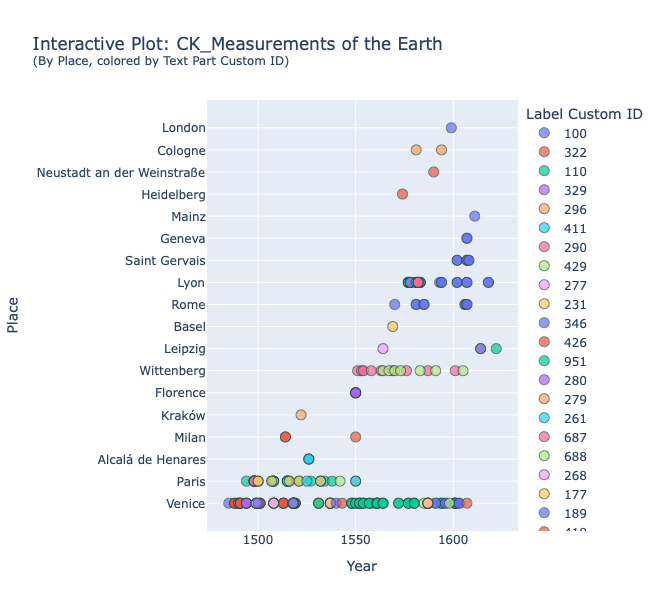

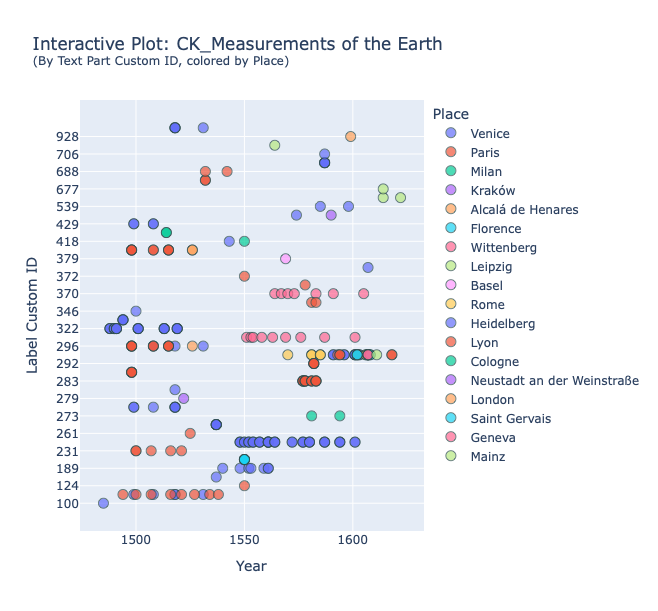

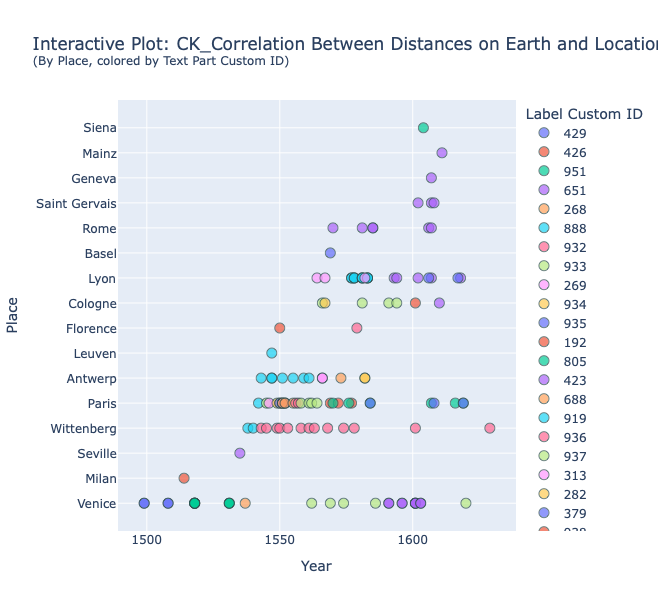

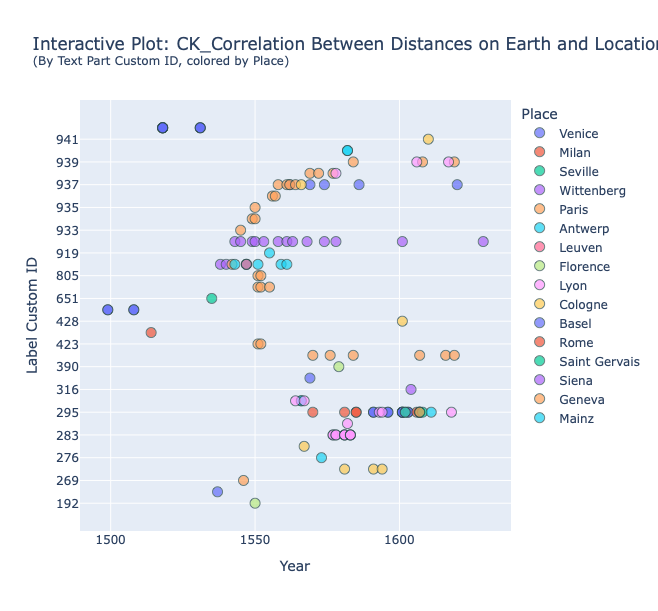

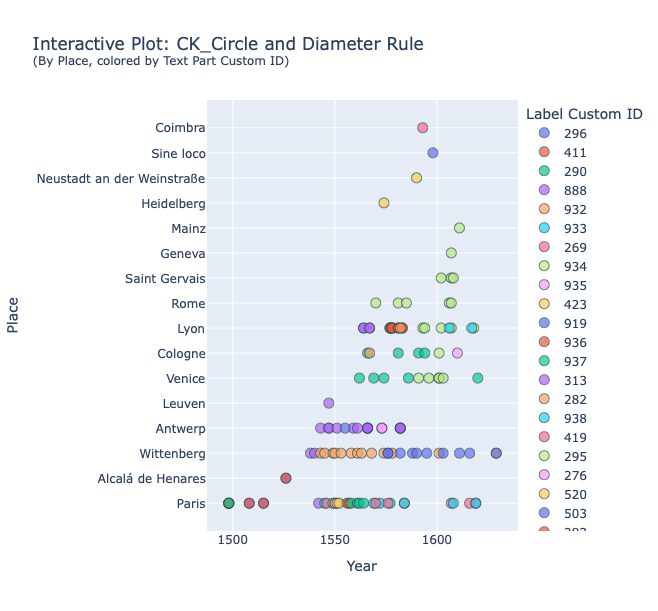

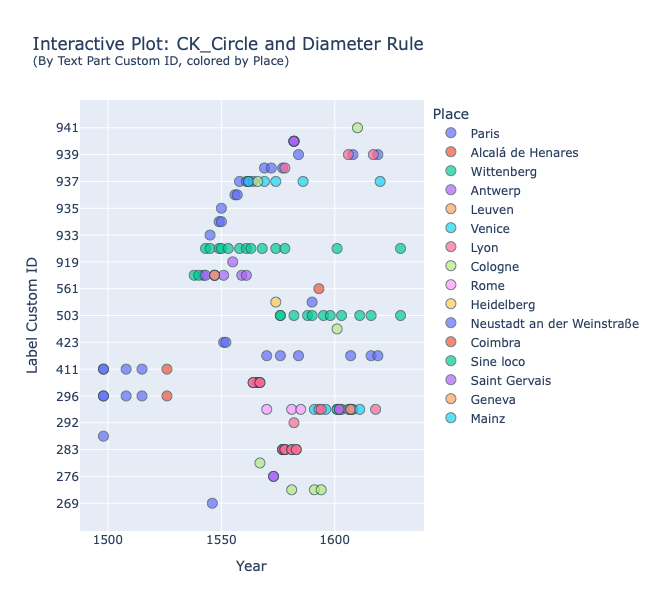

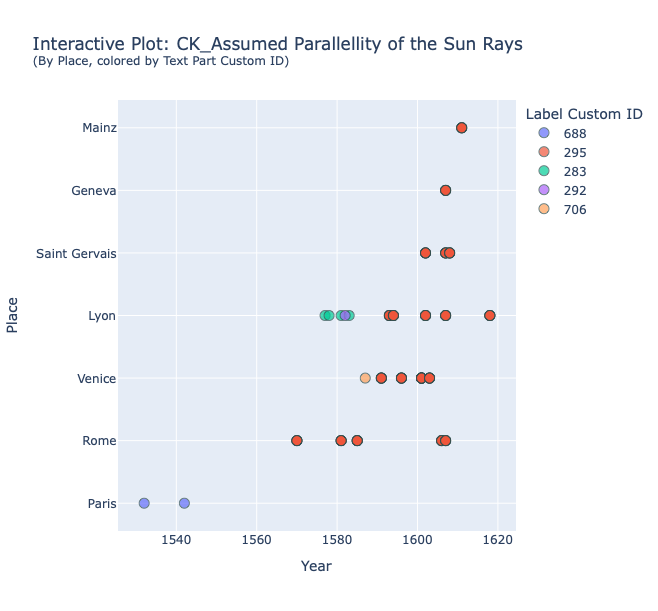

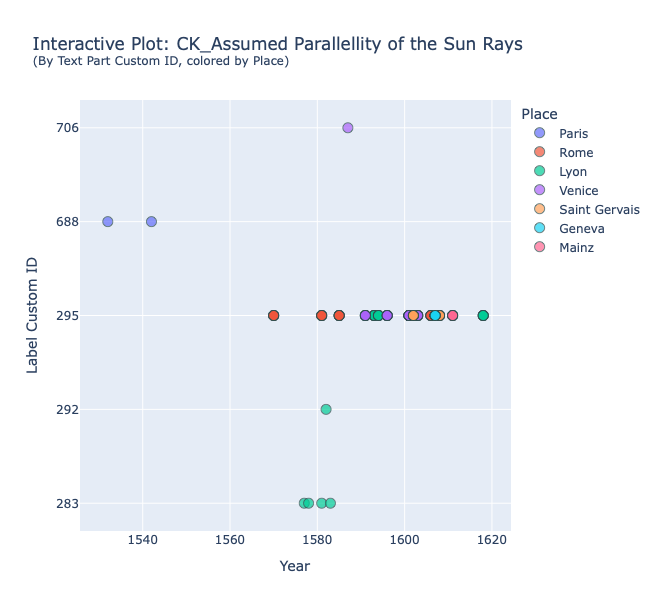

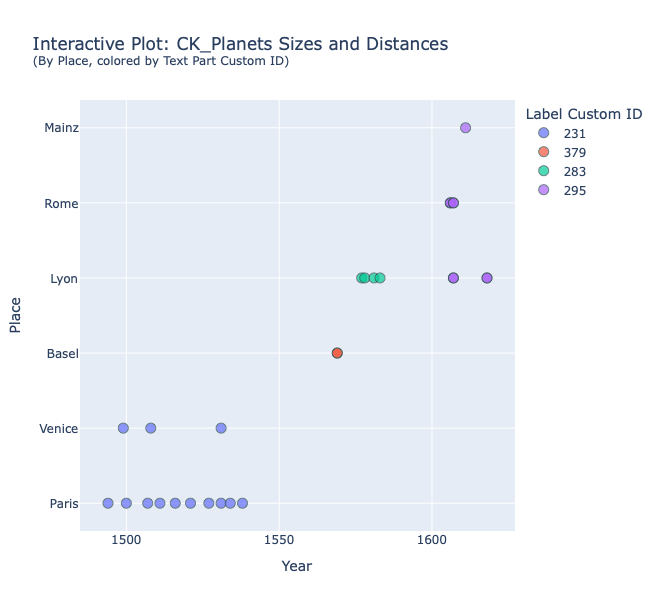

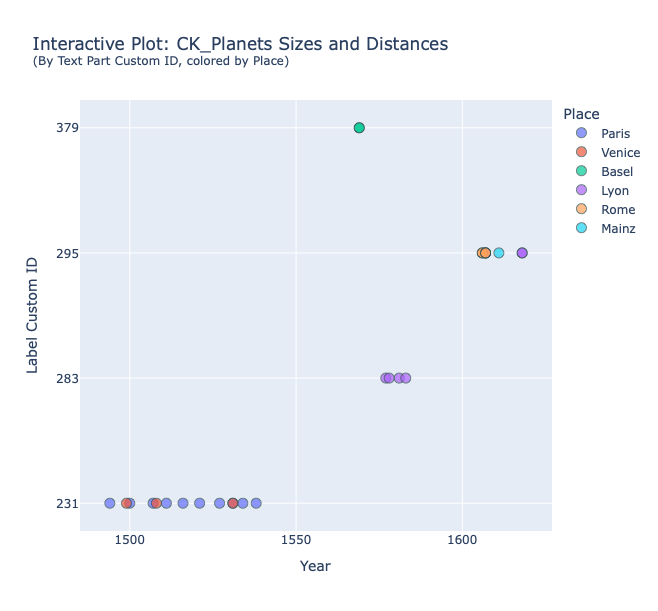

In [23]:
import plotly.express as px

print("\n--- Generating Interactive Dynamic Plots ---\n")

for keyword in target_cks:
    subgroup_df = df_clean[df_clean['cks'] == keyword].copy()
    
    if subgroup_df.empty:
        continue
        
    subgroup_df = subgroup_df.sort_values('year')
    
    fig_place = px.scatter(
        subgroup_df,
        x='year',
        y='place',
        color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: {keyword}<br><sup>(By Place, colored by Text Part Custom ID)</sup>',
        labels={'custom_identifier_str': 'Label Custom ID', 'place': 'Place', 'year': 'Year'}
    )
    fig_place.update_traces(marker=dict(size=10, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))
    fig_place.update_layout(height=600, hovermode='closest')
    fig_place.show()
    
    fig_id = px.scatter(
        subgroup_df,
        x='year',
        y='custom_identifier_str',
        color='place',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: {keyword}<br><sup>(By Text Part Custom ID, colored by Place)</sup>',
        labels={'custom_identifier_str': 'Label Custom ID', 'place': 'Place', 'year': 'Year'}
    )
    fig_id.update_traces(marker=dict(size=10, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))
    fig_id.update_yaxes(categoryorder='array', categoryarray=[str(i) for i in sorted([int(float(x)) for x in subgroup_df['custom_identifier_str'].unique() if str(x).replace('.','',1).isdigit()])])
    fig_id.update_layout(height=600, hovermode='closest')
    fig_id.show()
